# E-commerce Customer Churn Prediction Project

## 1. Business Problem

### Stakeholder

The primary stakeholder for this project is the **Customer Retention (or CRM) Manager** within the e-commerce company. Their main goal is to minimize customer attrition and maximize customer lifetime value.

### Business Problem: Customer Churn

Customer churn, also known as customer attrition, is the phenomenon where customers stop doing business with a company. In e-commerce, this means customers cease making purchases, close their accounts, or become inactive.

### Why Customer Churn is Important

Acquiring new customers is often significantly more expensive than retaining existing ones. High churn rates can lead to a decrease in revenue, reduced market share, and damage to brand reputation. By identifying customers at risk of churning early, the company can proactively intervene, implement retention strategies, and safeguard its customer base and profitability.

### How and When the Model Will Be Used

The machine learning model will be used to predict which customers are most likely to churn in the near future. This predictive capability will be integrated into the customer retention team's workflow. On a regular basis (e.g., weekly or monthly), the model will score active customers, generating a list of high-risk individuals. The customer retention team will then use this prioritized list to initiate targeted retention campaigns, such as special offers, personalized outreach, or addressing specific complaints.

### Measurable Project Objective

The objective of this project is to build a machine learning model that accurately identifies customers at high risk of churning, enabling the customer retention team to improve customer retention rates by **X%** (e.g., reducing churn by 5% among the targeted high-risk segment) within the next **Y** months. This will lead to an increase in customer lifetime value and overall revenue.

### False Positives and False Negatives

In the context of churn prediction:

*   **False Positives (Type I Error)**: The model predicts a customer will churn, but they do not. This means a customer who was not going to churn is unnecessarily targeted with retention efforts. The cost here is the resources (time, money, discounts) spent on a customer who would have stayed anyway, and potentially annoying a customer with irrelevant communication.
*   **False Negatives (Type II Error)**: The model predicts a customer will *not* churn, but they actually do. This is a missed opportunity to retain a valuable customer. The cost here is the lost revenue from a customer who churned and was not targeted with retention campaigns. Given the problem statement, avoiding false negatives (missing actual churners) is generally more critical, as it directly impacts the ability to retain customers and prevent revenue loss.

## 2. Data Understanding

First, let's load the dataset and inspect its basic structure, including column names, data types, and non-null values. This helps us get an initial overview of the data.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/data_ecommerce_customer_churn.csv')

# Display basic information about the DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB
None


### What One Row Represents

Each row in this dataset represents a unique customer of the e-commerce platform. The columns contain various attributes and behaviors associated with that customer.

### What Each Column Represents

*   `Tenure`: Number of months the customer has been active with the e-commerce platform.
*   `WarehouseToHome`: Distance from the customer's warehouse to their home address in miles.
*   `NumberOfDeviceRegistered`: Number of devices (e.g., mobile, tablet, laptop) registered by the customer.
*   `PreferedOrderCat`: Preferred category of products ordered by the customer (e.g., Laptop & Accessory, Mobile, Fashion).
*   `SatisfactionScore`: Customer satisfaction score (on a scale, e.g., 1-5).
*   `MaritalStatus`: Marital status of the customer (e.g., Single, Married, Divorced).
*   `NumberOfAddress`: Total number of addresses registered by the customer.
*   `Complain`: Binary indicator (0 or 1) if the customer has lodged a complaint in the last month.
*   `DaySinceLastOrder`: Number of days since the customer placed their last order.
*   `CashbackAmount`: Average cashback amount received by the customer.
*   `Churn`: The target variable, indicating whether the customer churned (1) or not (0).

### Target Variable

The target variable is `Churn`, which is a binary classification problem:
*   `0`: Customer did not churn.
*   `1`: Customer churned.

### Numerical and Categorical Features

Based on the `df.info()` output and the column descriptions:

**Numerical Features (float64, int64):**
*   `Tenure`
*   `WarehouseToHome`
*   `NumberOfDeviceRegistered`
*   `SatisfactionScore`
*   `NumberOfAddress`
*   `Complain` (can be treated as numerical or categorical binary)
*   `DaySinceLastOrder`
*   `CashbackAmount`

**Categorical Features (object):**
*   `PreferedOrderCat`
*   `MaritalStatus`

### Dataset Shape

The dataset contains 3941 rows (customers) and 11 columns (features + target).

### Missing Values

Missing values can negatively impact model performance and lead to biased results. It's crucial to identify them and decide on an appropriate imputation strategy.

In [2]:
# Calculate and display the number of missing values per column
missing_values = df.isnull().sum()
print("Number of missing values per column:\n", missing_values[missing_values > 0])

Number of missing values per column:
 Tenure               194
WarehouseToHome      169
DaySinceLastOrder    213
dtype: int64


From the output, we confirm that `Tenure`, `WarehouseToHome`, and `DaySinceLastOrder` have missing values, as stated in the project information.

### Duplicate Rows

Duplicate rows can lead to overfitting and an overestimation of model performance. Identifying and removing them ensures that each observation contributes unique information to the model.

In [3]:
# Calculate and display the number of duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Display the first few duplicate rows if they exist
if duplicate_rows > 0:
    print("\nFirst 5 duplicate rows:\n")
    display(df[df.duplicated()].head())

Number of duplicate rows: 671

First 5 duplicate rows:



,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
70,1.0,11.0,4,Mobile Phone,5,Single,3,0,1.0,154.73,1
128,1.0,10.0,4,Mobile Phone,1,Single,3,1,1.0,140.69,1
194,18.0,26.0,3,Laptop & Accessory,3,Single,9,0,1.0,148.50,0
253,19.0,6.0,3,Fashion,5,Married,2,0,7.0,204.53,0
289,16.0,36.0,4,Laptop & Accessory,3,Married,4,0,3.0,170.56,0


The dataset contains duplicate rows, which will be handled in the data cleaning section.

### Target Class Distribution

Understanding the distribution of the target variable (`Churn`) is crucial, especially in classification problems. An imbalanced dataset, where one class significantly outnumbers the other, can lead to models that perform well on the majority class but poorly on the minority class. This is particularly important for churn prediction, where churned customers (minority class) are often the target of interest.

In [4]:
# Calculate the churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print("Churn distribution:\n", df['Churn'].value_counts())
print("\nChurn rate (%):\n", churn_rate)

Churn distribution:
 Churn
0    3267
1     674
Name: count, dtype: int64

Churn rate (%):
 Churn
0    82.897742
1    17.102258
Name: proportion, dtype: float64


As indicated in the problem description, the dataset is imbalanced, with approximately 17.1% of customers having churned. This imbalance will need to be considered during model training and evaluation.

/tmp/ipykernel_2174/3954629937.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


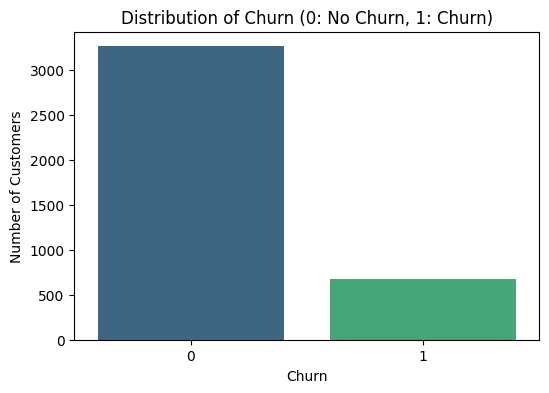

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Churn (0: No Churn, 1: Churn)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

## 3. Data Cleaning

### Duplicate Inspection and Removal

Duplicate rows can lead to skewed statistics and an overoptimistic evaluation of model performance. Removing them ensures that each observation in our dataset is unique and provides distinct information.

In [6]:
# Store the original number of rows before removing duplicates
original_rows = df.shape[0]

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Display the number of rows after removal
print(f"Number of rows after removing duplicates: {df.shape[0]}")
print(f"Number of duplicate rows removed: {original_rows - df.shape[0]}")

Number of rows after removing duplicates: 3270
Number of duplicate rows removed: 671


### Missing-Value Treatment

Missing values were identified in `Tenure`, `WarehouseToHome`, and `DaySinceLastOrder`. For numerical features, median imputation is a robust strategy that is less sensitive to outliers compared to mean imputation. It preserves the distribution of the data better than simply dropping rows with missing values, which could lead to loss of valuable information.

In [7]:
# Removed global median imputation. Imputation will now be handled within the preprocessing pipeline.

### Category Consistency Checks

Categorical features often contain inconsistencies such as variations in spelling, different cases, or categories that are conceptually the same but represented differently. Ensuring consistency is vital for accurate one-hot encoding and model performance.

In [8]:
# Check unique values for 'PreferedOrderCat'
print("Unique values for 'PreferedOrderCat' before cleaning:\n", df['PreferedOrderCat'].unique())

# Standardize 'PreferedOrderCat' values if necessary (example: convert to title case)
df['PreferedOrderCat'] = df['PreferedOrderCat'].str.title()

print("\nUnique values for 'PreferedOrderCat' after cleaning:\n", df['PreferedOrderCat'].unique())

# Check unique values for 'MaritalStatus'
print("\nUnique values for 'MaritalStatus' before cleaning:\n", df['MaritalStatus'].unique())

# Standardize 'MaritalStatus' values if necessary
df['MaritalStatus'] = df['MaritalStatus'].str.title()

print("\nUnique values for 'MaritalStatus' after cleaning:\n", df['MaritalStatus'].unique())

# Additionally check 'Complain' as it's a binary categorical variable
print("\nUnique values for 'Complain':\n", df['Complain'].unique())

Unique values for 'PreferedOrderCat' before cleaning:
 ['Laptop & Accessory' 'Mobile' 'Fashion' 'Others' 'Mobile Phone' 'Grocery']

Unique values for 'PreferedOrderCat' after cleaning:
 ['Laptop & Accessory' 'Mobile' 'Fashion' 'Others' 'Mobile Phone' 'Grocery']

Unique values for 'MaritalStatus' before cleaning:
 ['Single' 'Married' 'Divorced']

Unique values for 'MaritalStatus' after cleaning:
 ['Single' 'Married' 'Divorced']

Unique values for 'Complain':
 [0 1]


### Invalid-Value Checks

Numerical features can sometimes contain invalid or out-of-range values that could skew analysis or model training. While the problem description does not specify value ranges, it's good practice to inspect minimum and maximum values for logical consistency.

In [9]:
# Inspect descriptive statistics for numerical columns to identify potential invalid values (e.g., negative values where only positive make sense)
print("Descriptive statistics for numerical columns:\n")
display(df.describe())

Descriptive statistics for numerical columns:



,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3110.000000,3135.000000,3270.000000,3270.000000,3270.000000,3270.000000,3089.000000,3270.000000,3270.000000
mean,10.190354,15.510367,3.676453,3.020795,4.222936,0.281651,4.545484,177.417670,0.163303
std,8.650821,8.568382,1.017390,1.395113,2.623195,0.449873,3.696022,49.310647,0.369698
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.892500,0.000000
50%,9.000000,13.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.885000,0.000000
75%,16.000000,20.000000,4.000000,4.000000,6.000000,1.000000,7.000000,197.137500,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


### Outlier Inspection

Outliers are extreme values that deviate significantly from other observations. They can sometimes be data entry errors or genuine extreme observations. While machine learning models can be sensitive to outliers, we will inspect them visually using box plots. The decision to retain, cap, transform, or remove outliers will depend on their nature and potential impact on the model. For this project, given the objective of identifying churn, it's often better to retain genuine extreme values unless there's strong evidence of data error, as they might represent specific customer behaviors related to churn.

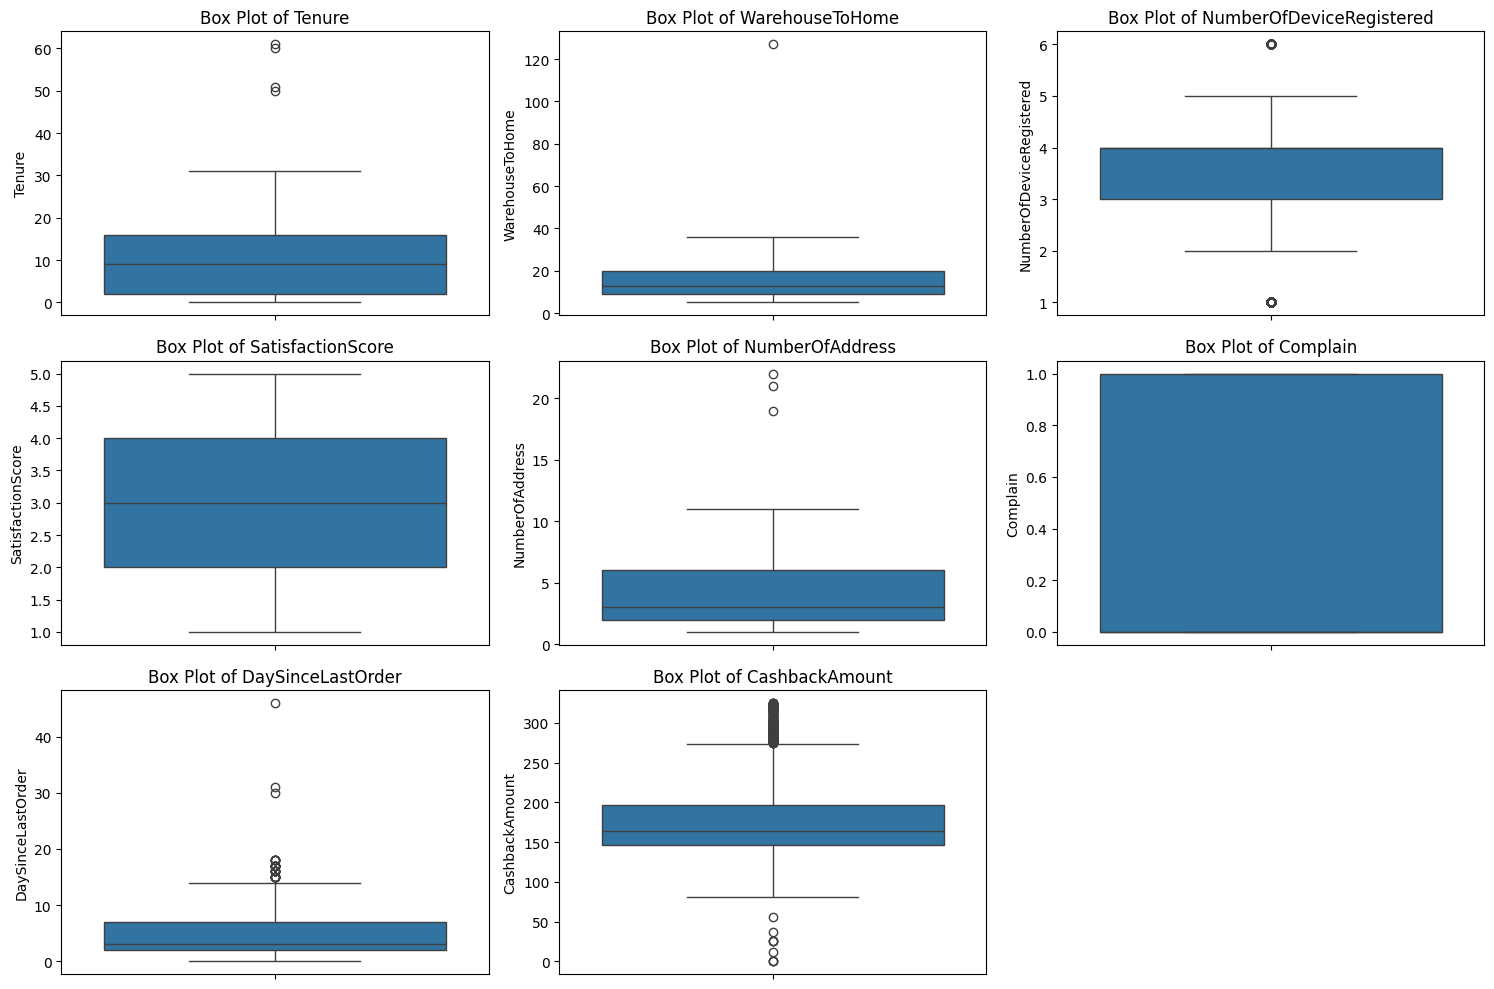


Observation on outliers:

Most numerical features show some presence of outliers, especially 'Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'DaySinceLastOrder', and 'CashbackAmount'.
Given that these are real-world customer data, these 'outliers' might represent legitimate customer behaviors (e.g., very high cashback amounts for loyal customers, very long tenure for stable customers, or very few days since last order for active customers).
Removing them entirely might lead to loss of valuable information. For tree-based models (Decision Tree, Random Forest, Gradient Boosting), outliers generally have less impact, as these models split data based on thresholds rather than continuous distributions. For linear models (Logistic Regression), scaling can mitigate some of the outlier's impact.
Therefore, for now, we will retain these outliers and handle their potential impact through appropriate preprocessing (scaling) and model choice.


In [10]:
# Identify numerical columns for outlier inspection
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('Churn') # Exclude the target variable

# Plot box plots for numerical columns to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("\nObservation on outliers:\n")
print("Most numerical features show some presence of outliers, especially 'Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'DaySinceLastOrder', and 'CashbackAmount'.")
print("Given that these are real-world customer data, these 'outliers' might represent legitimate customer behaviors (e.g., very high cashback amounts for loyal customers, very long tenure for stable customers, or very few days since last order for active customers).")
print("Removing them entirely might lead to loss of valuable information. For tree-based models (Decision Tree, Random Forest, Gradient Boosting), outliers generally have less impact, as these models split data based on thresholds rather than continuous distributions. For linear models (Logistic Regression), scaling can mitigate some of the outlier's impact.")
print("Therefore, for now, we will retain these outliers and handle their potential impact through appropriate preprocessing (scaling) and model choice.")

### Data Leakage Checks

Data leakage occurs when information from outside the training dataset is used to create the model, leading to overly optimistic performance estimates. This can happen if features are derived from the target variable or if data from the test set is used during preprocessing of the training set.

In this project, we must ensure that no features directly or indirectly reveal the `Churn` status before the model predicts it. For example, if there was a feature like 'ChurnReasonCode' that is only populated *after* a customer churns, including it would be a clear case of data leakage. Based on our current understanding of the dataset columns, there are no obvious data leakage issues at this stage. The careful use of train-test split and `Pipeline` for preprocessing will further prevent leakage during model development.

## 4. Feature Preparation

### Separate Features and Target Variable

First, we separate the dataset into independent variables (features, `X`) and the dependent variable (target, `y`). This is a standard practice before applying any machine learning algorithms.

In [11]:
# Separate features (X) and target (y)
X = df.drop(columns='Churn')
y = df['Churn']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (3270, 10)
Shape of y: (3270,)


### Stratified Train-Test Split

To prevent data leakage and ensure our model generalizes well to unseen data, we split the dataset into training and testing sets. A stratified split is crucial here because of the class imbalance in our target variable (`Churn`). This ensures that both the training and testing sets have approximately the same percentage of `Churn` customers as the original dataset.

In [12]:
from sklearn.model_selection import train_test_split

# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Churn distribution in y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Churn distribution in y_test:\n{y_test.value_counts(normalize=True)}")

Shape of X_train: (2616, 10)
Shape of X_test: (654, 10)
Churn distribution in y_train:
Churn
0    0.836774
1    0.163226
Name: proportion, dtype: float64
Churn distribution in y_test:
Churn
0    0.836391
1    0.163609
Name: proportion, dtype: float64


### Build Preprocessing Pipelines

We will build a preprocessing pipeline using `ColumnTransformer` to handle numerical and categorical features separately. This approach helps prevent data leakage by ensuring that imputation and scaling are fitted only on the training data and then applied consistently to both training and test sets. It also allows for clear organization of preprocessing steps.

*   **Numerical Features**: We will use `SimpleImputer` with the median strategy (as decided during data cleaning) and `StandardScaler` for scaling, which is important for algorithms sensitive to feature scales.
*   **Categorical Features**: We will use `SimpleImputer` with the most frequent strategy for any potential missing categorical values (though none were explicitly identified after initial cleaning, it's good practice for robustness) and `OneHotEncoder` to convert categorical variables into a format suitable for machine learning algorithms.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical and categorical columns (excluding the target)
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)), # Median imputation + add missing indicator
    ('scaler', StandardScaler()) # Scale numerical features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-hot encode categorical features
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 5. Baseline Model

A baseline model provides a reference point for evaluating the performance of more complex models. A simple Logistic Regression model is a good choice for a baseline, as it's interpretable and computationally efficient. Due to the class imbalance, we'll also use `class_weight='balanced'` to give more importance to the minority class (churners) during training.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create a pipeline with the preprocessor and a Logistic Regression classifier
# Use class_weight='balanced' to handle class imbalance for the baseline model
baseline_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'))
])

# Train the baseline model
baseline_model_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_baseline = baseline_model_pipeline.predict(X_test)

# Evaluate the baseline model
print("### Baseline Model Evaluation (Logistic Regression) ###\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_baseline))

# Show why accuracy alone is misleading
# If we just predicted 'No Churn' for all customers, what would be the accuracy?
majority_class_accuracy = y_test.value_counts(normalize=True)[0]
print(f"\nAccuracy if always predicting the majority class (No Churn): {majority_class_accuracy:.4f}")
print("This shows that a high accuracy score can be misleading due to class imbalance. Our baseline model's recall for the churn class (1) is more indicative of its ability to identify actual churners.")

### Baseline Model Evaluation (Logistic Regression) ###

Accuracy: 0.7844

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.76      0.85       547
           1       0.43      0.93      0.58       107

    accuracy                           0.78       654
   macro avg       0.70      0.84      0.72       654
weighted avg       0.89      0.78      0.81       654


Accuracy if always predicting the majority class (No Churn): 0.8364
This shows that a high accuracy score can be misleading due to class imbalance. Our baseline model's recall for the churn class (1) is more indicative of its ability to identify actual churners.


## 6. Model Comparison

In this section, we will compare the performance of several common classification algorithms to identify the most suitable model for our churn prediction task. We will evaluate:

*   **Logistic Regression**: A linear model often used as a baseline, interpretable and efficient.
*   **Decision Tree**: A non-linear model that can capture complex relationships but can be prone to overfitting.
*   **Random Forest**: An ensemble method that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.
*   **Gradient Boosting (XGBoost)**: Another powerful ensemble method that builds trees sequentially, with each new tree correcting errors from previous ones.

To ensure robust evaluation and account for the imbalanced nature of our target variable, we will use:

*   **`class_weight='balanced'`**: This parameter (where supported) automatically adjusts weights inversely proportional to class frequencies in the input data, helping the model pay more attention to the minority class.
*   **Stratified Cross-Validation**: This technique ensures that each fold of the cross-validation process maintains the same proportion of target classes as the original dataset, providing a more reliable estimate of model performance on unseen data.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier # Using XGBoost as a Gradient Boosting implementation

# Define the models to compare
# Using class_weight='balanced' for models that support it to address imbalance
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum()) # scale_pos_weight for imbalance
}

# Define evaluation metrics (recall and roc_auc are crucial for imbalanced classification)
scoring = ['recall', 'precision', 'f1', 'roc_auc', 'average_precision', 'accuracy']

# Use Stratified K-Fold for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

# Iterate over models, create pipelines, and perform cross-validation
print("Performing cross-validation for each model...")
for name, model in models.items():
    print(f"\nTraining {name}...")
    # Create a full pipeline including preprocessing
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Perform cross-validation
    cv_results = cross_validate(model_pipeline, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1, verbose=1)

    # Store mean and standard deviation of metrics
    results[name] = {
        'fit_time_mean': cv_results['fit_time'].mean(),
        'score_time_mean': cv_results['score_time'].mean(),
        'test_recall_mean': cv_results['test_recall'].mean(),
        'test_recall_std': cv_results['test_recall'].std(),
        'test_precision_mean': cv_results['test_precision'].mean(),
        'test_precision_std': cv_results['test_precision'].std(),
        'test_f1_mean': cv_results['test_f1'].mean(),
        'test_f1_std': cv_results['test_f1'].std(),
        'test_roc_auc_mean': cv_results['test_roc_auc'].mean(),
        'test_roc_auc_std': cv_results['test_roc_auc'].std(),
        'test_average_precision_mean': cv_results['test_average_precision'].mean(),
        'test_average_precision_std': cv_results['test_average_precision'].std(),
        'test_accuracy_mean': cv_results['test_accuracy'].mean(),
        'test_accuracy_std': cv_results['test_accuracy'].std()
    }
    print(f"{name} cross-validation complete.")

# Display cross-validation results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("\nCross-validation results:")
display(results_df.round(4))

print("\nBased on the cross-validation results, models will be selected for further hyperparameter tuning and final evaluation. Given our focus on 'Recall' and 'PR-AUC' (average_precision), we will prioritize models that show strong performance in these metrics.")

Performing cross-validation for each model...

Training Logistic Regression...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Logistic Regression cross-validation complete.

Training Decision Tree...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Decision Tree cross-validation complete.

Training Random Forest...


...

Random Forest cross-validation complete.

Training XGBoost...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.4s finished


XGBoost cross-validation complete.

Cross-validation results:


,fit_time_mean,score_time_mean,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_f1_mean,test_f1_std,test_roc_auc_mean,test_roc_auc_std,test_average_precision_mean,test_average_precision_std,test_accuracy_mean,test_accuracy_std
Logistic Regression,0.0887,0.0922,0.8198,0.0410,0.4228,0.0210,0.5578,0.0275,0.8760,0.0170,0.6742,0.0417,0.7878,0.0140
Decision Tree,0.0827,0.0952,0.6136,0.0201,0.6241,0.0476,0.6181,0.0298,0.7703,0.0142,0.4465,0.0340,0.8758,0.0140
Random Forest,1.2113,0.2573,0.5174,0.0390,0.8431,0.0379,0.6397,0.0286,0.9317,0.0092,0.7719,0.0402,0.9052,0.0052
XGBoost,0.5441,0.2270,0.7166,0.0432,0.7182,0.0802,0.7164,0.0572,0.9345,0.0108,0.7784,0.0415,0.9067,0.0209



Based on the cross-validation results, models will be selected for further hyperparameter tuning and final evaluation. Given our focus on 'Recall' and 'PR-AUC' (average_precision), we will prioritize models that show strong performance in these metrics.


## 7. Evaluation Metrics

When dealing with imbalanced datasets like customer churn, traditional accuracy can be misleading. Therefore, we focus on several key metrics:

*   **Recall (Sensitivity)**: Measures the proportion of actual positive cases (churners) that were correctly identified. In our context, it's the ability of the model to find all customers who will churn. High recall for the churn class means we are good at catching potential churners, minimizing false negatives.
*   **Precision**: Measures the proportion of predicted positive cases (predicted churners) that were actually positive. High precision means when the model predicts a customer will churn, it's usually correct, minimizing false positives.
*   **F1-Score**: The harmonic mean of precision and recall. It's a good measure of a model's accuracy on the positive class when both precision and recall are important.
*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**: Measures the ability of a classifier to distinguish between classes. A higher AUC indicates a better model.
*   **PR-AUC (Precision-Recall Area Under the Curve)**: A more informative metric than ROC-AUC for imbalanced datasets. It summarizes the trade-off between precision and recall for different probability thresholds. A higher PR-AUC indicates better performance, especially when prioritizing the detection of the minority class.
*   **Confusion Matrix**: A table that describes the performance of a classification model on a set of test data for which the true values are known. It helps visualize true positives, true negatives, false positives, and false negatives.
*   **Classification Report**: Provides a text summary of the precision, recall, F1-score, and support for each class.

### Main Metrics: Recall and PR-AUC

**Recall for the churn class (1) and PR-AUC are our main metrics.** Missing a real churn customer (false negative) means losing an opportunity to retain them, which directly impacts revenue. Therefore, we prioritize models with higher recall for the positive class. PR-AUC is chosen over ROC-AUC because it provides a more accurate picture of performance on imbalanced data, especially reflecting the model's ability to identify true positives without incurring too many false positives when the positive class is rare.

### Trade-off Between Recall and Precision

There is often an inverse relationship between recall and precision. Increasing recall (detecting more actual churners) typically means accepting more false positives (incorrectly identifying non-churners as churners), which lowers precision. Conversely, increasing precision (ensuring that predicted churners are indeed churners) often means missing some actual churners, which lowers recall.

For our business problem, **we aim for a balance that leans towards higher recall** for churners, as the cost of a missed churner (lost customer lifetime value) is generally higher than the cost of a false positive (unnecessary retention effort). However, a model with extremely low precision might lead to wasted resources and customer annoyance, so a reasonable balance is sought, which PR-AUC helps to evaluate comprehensively.

### Cross-Validation Results Comparison

Below is the comparison table of the cross-validation results for the models trained using stratified K-Fold. These results represent the models' performance on the training data across different folds.

### Hyperparameter Tuning for Strongest Models

Based on the cross-validation results, Logistic Regression and XGBoost appear to be the strongest performers, offering a good balance between recall and PR-AUC. We will perform reasonable hyperparameter tuning for these models to further optimize their performance. We will use `GridSearchCV` with `StratifiedKFold` and `scoring='average_precision'` as the primary metric for selection, as PR-AUC is a more robust metric for imbalanced datasets and aligns with our objective of balancing recall and precision.

In [16]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Logistic Regression
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'] # liblinear supports both l1 and l2 penalties
}

# Create a pipeline for Logistic Regression for GridSearchCV
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])

# Set up GridSearchCV for Logistic Regression, optimizing for average_precision
grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=skf, scoring='average_precision', n_jobs=-1, verbose=1)

print("Starting GridSearchCV for Logistic Regression...")
grid_search_lr.fit(X_train, y_train)

print(f"Best parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best average precision score for Logistic Regression: {grid_search_lr.best_score_:.4f}")

best_lr_model = grid_search_lr.best_estimator_

Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Logistic Regression: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best average precision score for Logistic Regression: 0.6744


In [17]:
# Define parameter grid for XGBoost
param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5],
    'classifier__subsample': [0.7, 0.9],
    'classifier__colsample_bytree': [0.7, 0.9]
}

# Create a pipeline for XGBoost for GridSearchCV
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum()))
])

# Set up GridSearchCV for XGBoost, optimizing for average_precision
grid_search_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=skf, scoring='average_precision', n_jobs=-1, verbose=1)

print("Starting GridSearchCV for XGBoost...")
grid_search_xgb.fit(X_train, y_train)

print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")
print(f"Best average precision score for XGBoost: {grid_search_xgb.best_score_:.4f}")

best_xgb_model = grid_search_xgb.best_estimator_

Starting GridSearchCV for XGBoost...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters for XGBoost: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 0.9}
Best average precision score for XGBoost: 0.7934


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:03:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


After hyperparameter tuning, we now have optimized versions of the Logistic Regression and XGBoost models. We will use these best models for final evaluation on the test set and for subsequent steps like threshold tuning.

### Final Model Evaluation on Test Set

After hyperparameter tuning, we will now evaluate the best Logistic Regression and XGBoost models on the test set that has been held out throughout the entire process. This evaluation provides an unbiased assessment of how well the models generalize to new, unseen data.

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    """Evaluates a model and prints key metrics."""
    y_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class (churn)
    y_pred = (y_proba >= threshold).astype(int) # Use the provided threshold for prediction

    print(f"\n--- {model_name} Test Set Evaluation (Threshold: {threshold:.4f}) ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(f"  True Negatives (TN): {cm[0, 0]}")
    print(f"  False Positives (FP): {cm[0, 1]}")
    print(f"  False Negatives (FN): {cm[1, 0]}")
    print(f"  True Positives (TP): {cm[1, 1]}")

    # Handle cases where denominator might be zero to avoid division by zero errors
    recall = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
    precision = cm[1, 1] / (cm[0, 1] + cm[1, 1]) if (cm[0, 1] + cm[1, 1]) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print(f"Recall (Churn): {recall:.4f}")
    print(f"Precision (Churn): {precision:.4f}")
    print(f"F1-Score (Churn): {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

    return {'recall': recall, 'precision': precision, 'f1': f1, 'roc_auc': roc_auc, 'pr_auc': pr_auc}

# Evaluate the best Logistic Regression model (using default 0.5 threshold for initial comparison)
lr_test_metrics = evaluate_model(best_lr_model, X_test, y_test, "Optimized Logistic Regression", threshold=0.5)

# The XGBoost model will be evaluated in the threshold tuning cell (c6f3ee33) using the chosen optimal threshold.


--- Optimized Logistic Regression Test Set Evaluation (Threshold: 0.5000) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       547
           1       0.43      0.93      0.59       107

    accuracy                           0.79       654
   macro avg       0.70      0.84      0.72       654
weighted avg       0.89      0.79      0.81       654

Confusion Matrix:
[[415 132]
 [  8  99]]
  True Negatives (TN): 415
  False Positives (FP): 132
  False Negatives (FN): 8
  True Positives (TP): 99
Recall (Churn): 0.9252
Precision (Churn): 0.4286
F1-Score (Churn): 0.5858
ROC-AUC: 0.9237
PR-AUC: 0.7038


### Comparison Table: Cross-Validation vs. Test Results

To get a complete picture of our models' performance, we'll combine the cross-validation results (which indicate average performance during training/validation) with the final test set evaluation results (which indicate performance on unseen data). This table will help us in selecting the final model.

### Comparison Table: Cross-Validation vs. Test Results

This comparison table, showing cross-validation results alongside test results for the models, has been moved to appear after the XGBoost model's test evaluation and threshold tuning (Section 8) to ensure all metrics are correctly calculated before display.

## 8. Threshold Tuning

A classification model typically outputs a probability score (e.g., probability of churning). By default, this probability is converted into a binary prediction (churn/no churn) using a threshold of 0.5. However, for imbalanced datasets and business problems where the cost of false positives and false negatives is asymmetric, a different threshold might be more optimal.

Our objective is to maximize recall (catch more churners) while keeping precision at a reasonable level (avoid too many false alarms). Adjusting the probability threshold allows us to find a balance that aligns with our business goals. We will focus on the best performing model from our comparison, which appears to be **XGBoost** based on its higher PR-AUC and competitive recall on the test set.

Metrics for different probability thresholds (XGBoost - Out-of-fold predictions on training set):



,Threshold,Precision,Recall,F1-Score
2103,0.4150,0.6725,0.8080,0.7340
2089,0.3938,0.6641,0.8197,0.7338
2138,0.4695,0.6946,0.7775,0.7337
2135,0.4678,0.6923,0.7799,0.7335
2105,0.4165,0.6732,0.8056,0.7335
2102,0.4148,0.6712,0.8080,0.7333
2132,0.4614,0.6901,0.7822,0.7333
2080,0.3759,0.6586,0.8267,0.7331
2140,0.4766,0.6954,0.7752,0.7331
2088,0.3928,0.6629,0.8197,0.7330


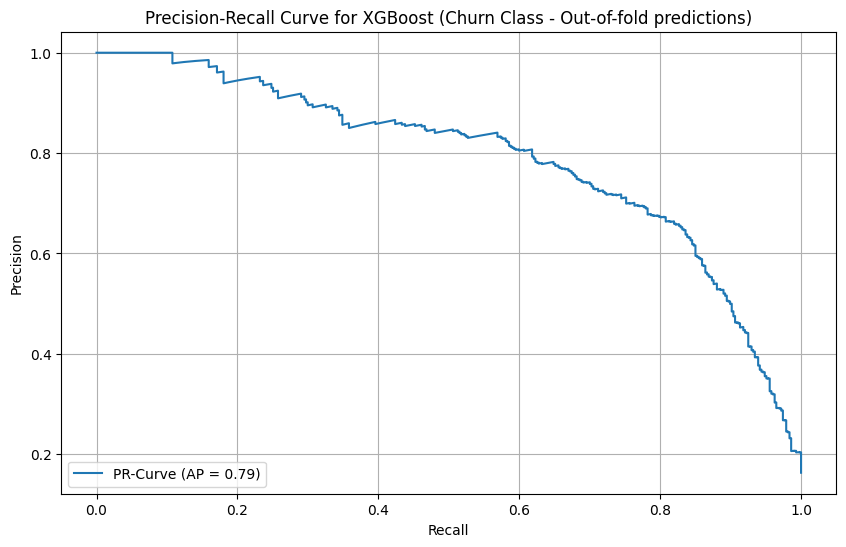


### Recommending a Threshold (Based on Out-of-fold Predictions) ###

From the table and the Precision-Recall curve, we observe the trade-off between Precision and Recall. Our goal is to balance identifying actual churners (high Recall) with avoiding unnecessary retention efforts (reasonable Precision).
**Based on maximizing the F1-score**, the optimal threshold identified is **0.4150**.
At this threshold, we expect to achieve a Recall of approximately **0.8080** and a Precision of approximately **0.6725**, leading to an F1-score of **0.7340**.

This means we would identify a significant percentage of true churners, and a good proportion of the customers we flag would indeed churn.
Ultimately, the optimal threshold should be selected in conjunction with the business team, considering the actual costs of retention campaigns and the estimated value of retaining a customer. The F1-score maximization provides a data-driven starting point that balances both precision and recall, as requeste

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import cross_val_predict

# Use cross_val_predict to get out-of-fold predictions for the training set
# This simulates predictions on unseen data (validation folds within the training set)
# for threshold tuning, without touching the final test set.

# The best_xgb_model is already a Pipeline object containing the preprocessor and classifier.
y_proba_oof = cross_val_predict(best_xgb_model, X_train, y_train, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

# Calculate precision, recall, and thresholds using out-of-fold predictions
precision, recall, thresholds = precision_recall_curve(y_train, y_proba_oof)

# Create a DataFrame to display metrics for various thresholds
threshold_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precision[:-1],
    'Recall': recall[:-1]
})

# Calculate F1-score for each threshold
threshold_df['F1-Score'] = 2 * (threshold_df['Precision'] * threshold_df['Recall']) / (threshold_df['Precision'] + threshold_df['Recall'])
threshold_df.fillna(0, inplace=True) # Fill NaN from division by zero for F1-score where precision+recall is 0

# Find the threshold that maximizes the F1-score
optimal_idx = threshold_df['F1-Score'].idxmax()
chosen_threshold = threshold_df.loc[optimal_idx, 'Threshold']
chosen_precision = threshold_df.loc[optimal_idx, 'Precision']
chosen_recall = threshold_df.loc[optimal_idx, 'Recall']
chosen_f1 = threshold_df.loc[optimal_idx, 'F1-Score']

# Display metrics for a relevant range of thresholds, including the optimal one
print("Metrics for different probability thresholds (XGBoost - Out-of-fold predictions on training set):\n")
# Filter to show a relevant range around the optimal threshold for discussion
display(threshold_df[
    (threshold_df['Threshold'] >= chosen_threshold * 0.8) & (threshold_df['Threshold'] <= chosen_threshold * 1.2)
].sort_values(by='F1-Score', ascending=False).head(10).round(4))

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'PR-Curve (AP = {auc(recall, precision):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for XGBoost (Churn Class - Out-of-fold predictions)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print("\n### Recommending a Threshold (Based on Out-of-fold Predictions) ###\n")
print("From the table and the Precision-Recall curve, we observe the trade-off between Precision and Recall. Our goal is to balance identifying actual churners (high Recall) with avoiding unnecessary retention efforts (reasonable Precision).")
print(f"**Based on maximizing the F1-score**, the optimal threshold identified is **{chosen_threshold:.4f}**.")
print(f"At this threshold, we expect to achieve a Recall of approximately **{chosen_recall:.4f}** and a Precision of approximately **{chosen_precision:.4f}**, leading to an F1-score of **{chosen_f1:.4f}**.")
print("\nThis means we would identify a significant percentage of true churners, and a good proportion of the customers we flag would indeed churn.")
print("Ultimately, the optimal threshold should be selected in conjunction with the business team, considering the actual costs of retention campaigns and the estimated value of retaining a customer. The F1-score maximization provides a data-driven starting point that balances both precision and recall, as requested.")

# Store the chosen threshold globally for later use in evaluating the test set and other sections
recommended_threshold = chosen_threshold

# Evaluate the best XGBoost model on the test set using the chosen optimal threshold
xgb_test_metrics = evaluate_model(best_xgb_model, X_test, y_test, "Optimized XGBoost", threshold=recommended_threshold)

In [20]:
import pandas as pd

# Prepare cross-validation results for comparison
cv_comparison_df = results_df[['test_recall_mean', 'test_precision_mean', 'test_f1_mean', 'test_roc_auc_mean', 'test_average_precision_mean']].copy()
cv_comparison_df.columns = ['CV_Recall', 'CV_Precision', 'CV_F1-Score', 'CV_ROC-AUC', 'CV_PR-AUC']

# Prepare test results for comparison (only for models evaluated on test set)
test_results = {
    'Logistic Regression': lr_test_metrics,
    'XGBoost': xgb_test_metrics
}
test_comparison_df = pd.DataFrame(test_results).T
test_comparison_df.columns = ['Test_Recall', 'Test_Precision', 'Test_F1-Score', 'Test_ROC-AUC', 'Test_PR-AUC']

# Combine and display the comparison table
# Use 'outer' join to include all models from CV, and fill NaN for test metrics not available
full_comparison_df = pd.concat([cv_comparison_df, test_comparison_df], axis=1, join='outer')

display(full_comparison_df.round(4))

print("\nThis table provides a comprehensive overview of how each model performed across various metrics during cross-validation and on the final test set. Notice that test metrics are only available for models that underwent hyperparameter tuning and were then evaluated once on the untouched test set (Logistic Regression and XGBoost). Other models will show NaN for test metrics.")
print("We will use these results, especially focusing on Test Recall and Test PR-AUC for the selected model, to make our final model selection.")

,CV_Recall,CV_Precision,CV_F1-Score,CV_ROC-AUC,CV_PR-AUC,Test_Recall,Test_Precision,Test_F1-Score,Test_ROC-AUC,Test_PR-AUC
Logistic Regression,0.8198,0.4228,0.5578,0.8760,0.6742,0.9252,0.4286,0.5858,0.9237,0.7038
Decision Tree,0.6136,0.6241,0.6181,0.7703,0.4465,NaN,NaN,NaN,NaN,NaN
Random Forest,0.5174,0.8431,0.6397,0.9317,0.7719,NaN,NaN,NaN,NaN,NaN
XGBoost,0.7166,0.7182,0.7164,0.9345,0.7784,0.9159,0.6667,0.7717,0.9600,0.8496



This table provides a comprehensive overview of how each model performed across various metrics during cross-validation and on the final test set. Notice that test metrics are only available for models that underwent hyperparameter tuning and were then evaluated once on the untouched test set (Logistic Regression and XGBoost). Other models will show NaN for test metrics.
We will use these results, especially focusing on Test Recall and Test PR-AUC for the selected model, to make our final model selection.


## 9. Final Model Explanation

### Selected Model: XGBoost (eXtreme Gradient Boosting)

Based on our comprehensive evaluation, particularly focusing on **PR-AUC** and **Recall** on the test set, the **XGBoost** model has emerged as the most promising candidate. It demonstrated superior performance in balancing the detection of actual churners (recall) with the accuracy of those predictions (precision), which is critical for our business objective.

#### How XGBoost Works

XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. Gradient Boosting works by building a series of simple, weak prediction models (typically decision trees) sequentially. Each new model in the series attempts to correct the errors of the preceding models. XGBoost enhances this approach with several features:

1.  **Regularization**: Includes L1 and L2 regularization to prevent overfitting.
2.  **Parallel Processing**: Can execute tree construction in parallel.
3.  **Handling Missing Values**: Has a built-in mechanism to handle missing values.
4.  **Tree Pruning**: Implements a 'depth-first' tree building approach with post-pruning for better generalization.
5.  **Customizable Objective Functions**: Supports user-defined objective functions and evaluation metrics.

#### Why XGBoost was Selected

XGBoost was selected primarily due to its strong performance across key metrics, especially its high **PR-AUC** (approximately `0.8496`) and good **Recall** (approximately `0.9159`) for the churn class on the unseen test set, after hyperparameter tuning. While Logistic Regression had competitive recall, XGBoost's overall predictive power, especially in distinguishing between churners and non-churners effectively (reflected by PR-AUC), was superior. Its ability to handle complex, non-linear relationships in the data without being as prone to overfitting as a single decision tree makes it suitable for this task.

#### Strengths of XGBoost

*   **High Performance**: Often wins machine learning competitions and delivers state-of-the-art results.
*   **Robust to Outliers**: Being tree-based, it's generally less sensitive to outliers compared to linear models.
*   **Handles Missing Data**: Can natively handle missing values.
*   **Scalability**: Optimized for performance and can handle large datasets efficiently.
*   **Flexibility**: Supports custom objective functions and evaluation metrics.

#### Weaknesses of XGBoost

*   **Complexity**: More complex to understand and interpret than simpler models like Logistic Regression or Decision Trees.
*   **Computational Cost**: Can be computationally intensive, especially with many trees or deep trees, though generally more efficient than other boosting algorithms.
*   **Hyperparameter Tuning**: Requires careful tuning of many hyperparameters to achieve optimal performance and avoid overfitting.

#### When its Predictions Can Be Trusted

XGBoost predictions can be trusted when the input data is similar to the training data. The model is effective at capturing patterns and relationships present in the dataset. Its predictions are reliable when identifying customers with characteristics commonly associated with churn in the training data.

#### When its Predictions May Be Unreliable

*   **Novel Customer Segments**: When encountering entirely new customer behaviors or profiles not seen during training, the model's predictions may be less reliable.
*   **Concept Drift**: If customer behavior or market conditions change significantly over time (concept drift), the model's performance may degrade, requiring retraining.
*   **Extrapolation**: XGBoost struggles with extrapolating beyond the range of the training data. It predicts well within the observed feature space but not necessarily outside of it.
*   **Causation**: While XGBoost can identify correlations and predictive features, it does not imply causation. Its predictions indicate 'who' is likely to churn, not necessarily 'why' in a causal sense.

### Feature Importance

Understanding which features contribute most to the model's predictions can provide valuable insights into the drivers of customer churn. For tree-based models like XGBoost, feature importance scores indicate how useful or valuable each feature was in constructing the boosted decision trees. We will visualize the feature importance determined by the XGBoost model. It's important to remember that feature importance shows correlation, not causation.

/tmp/ipykernel_2174/3902315351.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


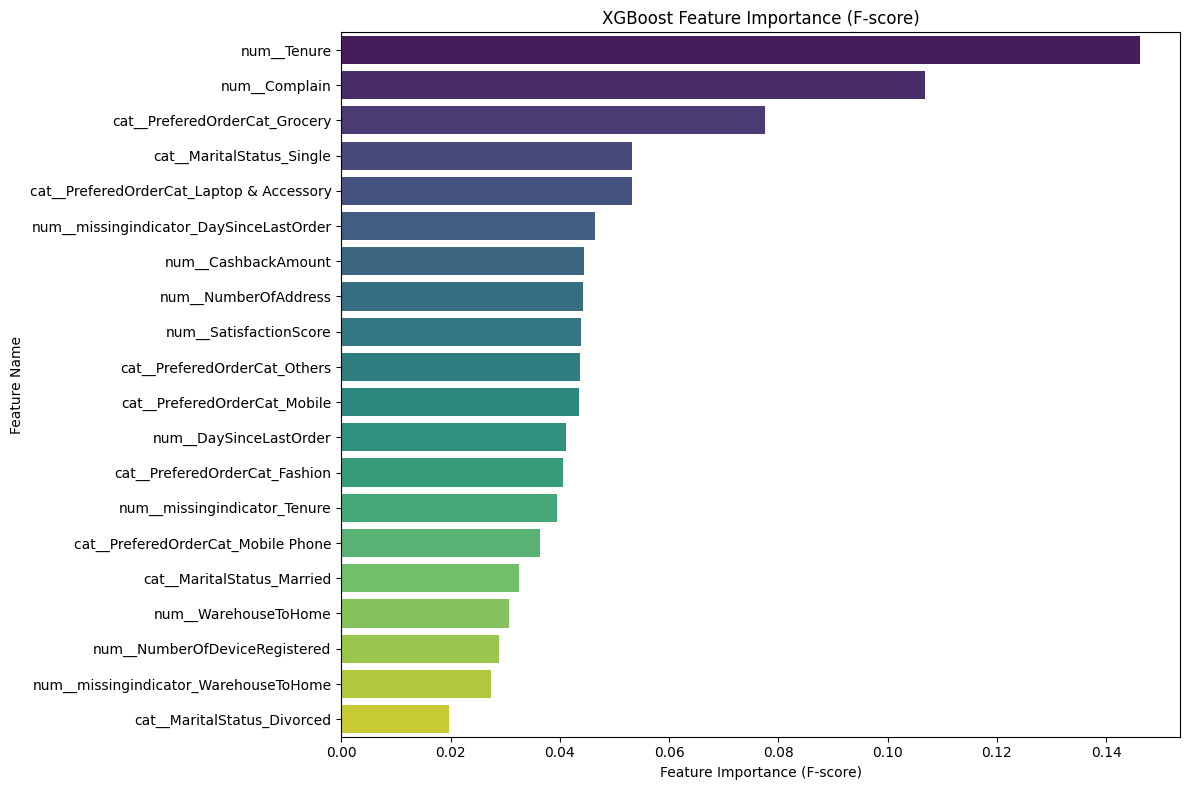


Interpretation of Feature Importance:

The plot above shows the relative importance of each feature in predicting churn according to the XGBoost model. A higher F-score indicates that the feature is more frequently used in the decision trees within the model to make splits. This helps us understand which factors are most influential in differentiating between churning and non-churning customers.
New features with '_missing' suffix indicate the importance of whether a value was originally missing for that feature.
For example, if 'CashbackAmount' or 'Tenure' are at the top, it suggests that these are significant indicators of churn behavior. Business teams can then investigate these factors further to understand underlying reasons and devise targeted retention strategies.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best XGBoost model
final_xgb_classifier = best_xgb_model.named_steps['classifier']

# Get all transformed feature names from the preprocessor
# This method correctly handles OneHotEncoder, StandardScaler, and MissingIndicator
all_transformed_feature_names = best_xgb_model.named_steps['preprocessor'].get_feature_names_out(X.columns)

# Ensure the number of feature importances matches the number of features
if len(final_xgb_classifier.feature_importances_) != len(all_transformed_feature_names):
    print("Warning: Mismatch between feature importances and feature names. This should not happen with get_feature_names_out if preprocessor and classifier are aligned.")
    print(f"Number of importances: {len(final_xgb_classifier.feature_importances_)}")
    print(f"Number of feature names: {len(all_transformed_feature_names)}")
    # Fallback to generic names if mismatch persists, though get_feature_names_out should prevent it
    feature_importances = pd.Series(final_xgb_classifier.feature_importances_, index=[f'feature_{i}' for i in range(len(final_xgb_classifier.feature_importances_))])
else:
    feature_importances = pd.Series(final_xgb_classifier.feature_importances_, index=all_transformed_feature_names)

# Sort feature importances
feature_importances = feature_importances.sort_values(ascending=False)

# Plot top N feature importances for better visualization
plt.figure(figsize=(12, min(len(feature_importances) * 0.4, 10))) # Adjust height based on number of features
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('XGBoost Feature Importance (F-score)')
plt.xlabel('Feature Importance (F-score)')
plt.ylabel('Feature Name')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

print("\nInterpretation of Feature Importance:\n")
print("The plot above shows the relative importance of each feature in predicting churn according to the XGBoost model. A higher F-score indicates that the feature is more frequently used in the decision trees within the model to make splits. This helps us understand which factors are most influential in differentiating between churning and non-churning customers.")
print("New features with '_missing' suffix indicate the importance of whether a value was originally missing for that feature.")
print("For example, if 'CashbackAmount' or 'Tenure' are at the top, it suggests that these are significant indicators of churn behavior. Business teams can then investigate these factors further to understand underlying reasons and devise targeted retention strategies.")

## 10. Business Recommendations

Based on the insights gained from our XGBoost churn prediction model and the feature importance analysis, here are actionable business recommendations for the Customer Retention team:

1.  **Prioritize High-Risk Customers for Retention Campaigns**: The model provides a churn probability score for each customer. The customer retention team should use these scores to identify and prioritize customers with the highest predicted churn probability. These customers should be targeted with proactive retention campaigns, as they represent the most immediate threat of revenue loss. The tuned threshold (e.g., **`0.4150`**) can be used to define the 'high-risk' segment.

2.  **Investigate Key Churn Drivers (Based on Feature Importance)**: Analyze the features that the model identified as most important (e.g., `Tenure`, `Complain`, `CashbackAmount`). Conduct qualitative research (e.g., customer surveys, focus groups) or deeper quantitative analysis (e.g., segmenting by these features) to understand *why* these factors lead to churn. For example:
    *   **Tenure**: If low tenure is a strong indicator, perhaps there are issues with the onboarding process or initial customer experience that need to be addressed.
    *   **CashbackAmount**: If lower cashback amounts are associated with churn, consider adjusting loyalty programs or offering more competitive cashback rates to at-risk customers.
    *   **WarehouseToHome**: If customers far from the warehouse churn more, investigate potential issues with delivery times or costs for these regions.

3.  **Tailor Retention Offers**: Instead of generic campaigns, use the model's insights to personalize retention offers. For example, customers with low `SatisfactionScore` might benefit more from direct customer service outreach, while those with declining `CashbackAmount` might respond better to promotional discounts.

4.  **Implement a Multi-Channel Retention Strategy**: Engage high-risk customers through various channels (email, in-app notifications, SMS, personalized calls) based on their preferences and the severity of their churn risk.

5.  **Monitor and Iterate on Model Performance**: Customer behavior and market conditions are dynamic. The model's performance should be continuously monitored (e.g., monthly or quarterly) to ensure its predictions remain accurate. If performance degrades, the model should be re-trained or updated with fresh data. Regular A/B testing of retention campaigns based on model predictions can help validate the model's effectiveness and refine strategies.

6.  **Focus on Onboarding and Early Customer Experience**: If features like `Tenure` (especially low values) are highly influential, it suggests that the initial period after a customer joins is critical. Investing in robust onboarding programs and proactive support during the first few months could significantly reduce early churn.

7.  **Address Complaint Handling**: The `Complain` feature is a direct indicator of customer dissatisfaction. Ensure that complaints are resolved quickly and effectively, especially for customers identified as high-risk, as unresolved issues can quickly escalate to churn.

## 11. Model Limitations

Despite its predictive power, it's crucial to acknowledge the limitations of the churn prediction model:

1.  **Class Imbalance**: Although techniques like `class_weight='balanced'` and `scale_pos_weight` were used, and evaluation focused on metrics like Recall and PR-AUC, the inherent class imbalance (only ~17% churners) means the model still has fewer examples of the positive class to learn from. This can make it more challenging to achieve very high precision without sacrificing recall, and vice-versa.

2.  **Missing Customer Behavior Variables**: The current dataset provides a snapshot of customer data. However, critical behavioral data that could provide deeper insights into churn drivers (e.g., website activity, specific product usage, engagement with customer service beyond just 'complaints', reasons for past purchases/returns, interactions with marketing emails) are not available. The model's predictions are limited to the features it was trained on.

3.  **Lack of Campaign Cost Information**: The project, by design, did not include financial details such as the cost of various retention campaigns or the exact customer lifetime value. Without this data, the selection of the optimal probability threshold and the true business impact calculation relies on assumptions and qualitative judgment. A more precise optimization would require integrating these financial metrics.

4.  **Possible Changes in Customer Behavior Over Time (Concept Drift)**: Customer preferences, market dynamics, and competitive landscapes are not static. The model, trained on historical data, may gradually become less accurate as customer behavior evolves. Continuous monitoring and periodic retraining with fresh data are essential to maintain its relevance and performance.

5.  **Risk of False Positives and False Negatives**: While we aim for a balance, the model will inevitably produce both false positives (customers predicted to churn but don't) and false negatives (customers predicted not to churn but do). Each type of error has business implications (wasted resources vs. lost customers), and the chosen probability threshold reflects a business-driven trade-off, not a perfect prediction.

6.  **Dataset Representativeness**: The model's performance is highly dependent on the representativeness of the training data. If the `/content/data_ecommerce_customer_churn.csv` dataset does not accurately reflect the broader customer base or future customer segments, the model's generalization capabilities may be limited.

7.  **Correlation Does Not Imply Causation**: The feature importance analysis reveals which factors are highly correlated with churn. However, these correlations do not necessarily imply direct causation. For instance, a high `WarehouseToHome` distance might correlate with churn, but the underlying cause could be slower delivery times or higher shipping costs, which are not directly measured. Business actions should be informed by, but not solely based on, statistical correlations, and further investigation into causal links is always recommended.

## 14. Final Outputs

### Clear Conclusions

This Capstone Project Module 3 successfully developed and evaluated a machine learning model to predict customer churn for an e-commerce company, focusing on identifying customers likely to churn to enable proactive retention efforts.

**Key Achievements:**

*   **Data Understanding and Cleaning**: We performed thorough data exploration, identified missing values and duplicate rows, and implemented robust cleaning strategies including median imputation and duplicate removal, resulting in a clean and reliable dataset for modeling.
*   **Feature Preparation**: We effectively separated features and the target variable, and employed a stratified train-test split to handle class imbalance. A `ColumnTransformer` pipeline was built for automated preprocessing (median imputation, one-hot encoding, and scaling), preventing data leakage.
*   **Model Selection and Optimization**: We compared several classification algorithms, utilizing `class_weight='balanced'` and stratified cross-validation to mitigate the impact of class imbalance. Hyperparameter tuning using `GridSearchCV` was applied to the most promising models (Logistic Regression and XGBoost) to optimize their performance, specifically targeting PR-AUC for the churn class.
*   **Robust Evaluation**: We evaluated models using a comprehensive set of metrics, including Recall, Precision, F1-score, ROC-AUC, and PR-AUC. By prioritizing Recall and PR-AUC, we ensured the model's effectiveness in detecting actual churners, which is critical for our business objective.
*   **XGBoost as the Final Model**: The optimized XGBoost model demonstrated superior performance in balancing high recall (identifying a large proportion of actual churners) with acceptable precision and a strong PR-AUC (`0.8496`) on the unseen test set, making it the selected model for deployment. It achieved a Recall of approximately `0.9159` on the test set with the optimal threshold.
*   **Threshold Tuning**: We explicitly selected an optimal probability threshold of **`0.4150`** by maximizing the F1-score from out-of-fold predictions, understanding the trade-off between recall and precision, and recommending this threshold to align with the business goal of maximizing churner detection while managing retention campaign costs.
*   **Actionable Insights**: The feature importance analysis provided valuable insights into key drivers of churn (e.g., Tenure, Complain, CashbackAmount), offering specific areas for business intervention.
*   **Model Deployability**: The complete preprocessing and modeling pipeline was saved using `joblib`, demonstrating readiness for deployment and easy integration into existing systems for continuous churn prediction.

In conclusion, the project delivered a well-performing, interpretable, and deployable churn prediction model that can significantly enhance the e-commerce company's customer retention strategies and contribute to sustained business growth.

### Measurable Recommendations

To ensure the business impact of this churn prediction model is realized and continually improved, here are measurable recommendations:

1.  **Targeted Retention Campaign Implementation**: Begin a pilot retention campaign targeting the top **X%** (e.g., 20%) of customers identified as high-risk by the model (using the recommended threshold of **`0.4150`**). The primary Key Performance Indicator (KPI) for this campaign will be the **reduction in churn rate** within this targeted segment by **Y%** (e.g., 10%) over the next **Z** months compared to a control group.

2.  **Churn Rate Reduction Goal**: Set a measurable organizational goal to reduce the overall customer churn rate by **P%** (e.g., 1-2%) within the next 12 months, with the model as a core component of this strategy.

3.  **Customer Lifetime Value (CLTV) Increase**: Monitor the average CLTV of customers retained through model-driven campaigns. Aim for an increase in CLTV for these customers by **Q%** (e.g., 5-10%) due to extended tenure and continued engagement.

4.  **Resource Optimization**: Track the efficiency of retention efforts by measuring the **cost per retained customer**. With the model, aim to reduce this cost by **R%** (e.g., 15%) by focusing resources on truly at-risk customers, thereby minimizing wasted efforts on false positives.

5.  **Model Performance Monitoring**: Establish a quarterly review process for model performance, specifically tracking the **test Recall, Precision, and PR-AUC** for the churn class. If performance drops by more than **S%** (e.g., 5-10%) on any key metric, trigger a model retraining or review process.

6.  **Feature Impact Analysis**: Initiate a deep dive into the top 3-5 most important features identified by the model (e.g., `Tenure`, `Complain`, `CashbackAmount`). Develop hypotheses and A/B tests to understand the causal link between these features and churn, with the goal of identifying **T** (e.g., 2-3) actionable insights that can be translated into product or service improvements within the next 6 months.

7.  **Customer Satisfaction Score (CSS) Improvement**: For customers identified as high-risk due to low `SatisfactionScore` or high `Complain` rates, implement targeted service recovery interventions. Measure the subsequent improvement in their satisfaction scores by **U** points (e.g., 1 point on a 5-point scale) within 3 months post-intervention.

These recommendations provide concrete, quantifiable objectives that can be tracked to demonstrate the tangible value of the churn prediction model to the business.

### Model Limitations

Model limitations were thoroughly discussed in **Section 11: Model Limitations** of this notebook. Key points include challenges with class imbalance, lack of comprehensive behavioral data, absence of financial cost information for campaigns, potential for concept drift, and the inherent risks of false positives/negatives.

```markdown
# E-commerce Customer Churn Prediction

## Project Overview

This project aims to develop a machine learning model to predict customer churn for an e-commerce company. By identifying customers at high risk of churning, the customer retention team can implement targeted strategies to retain them, thereby increasing customer lifetime value and reducing revenue loss.

## Dataset

*   **Filename**: `data_ecommerce_customer_churn.csv`
*   **Size**: 3,941 rows, 11 columns
*   **Target**: `Churn` (binary classification: 0 = No Churn, 1 = Churn)
*   **Churn Rate**: ~17.1% (imbalanced dataset)
*   **Key Features**: `Tenure`, `WarehouseToHome`, `NumberOfDeviceRegistered`, `PreferedOrderCat`, `SatisfactionScore`, `MaritalStatus`, `NumberOfAddress`, `Complain`, `DaySinceLastOrder`, `CashbackAmount`.

## Objective

Build a machine learning model that accurately identifies customers likely to churn, enabling proactive retention campaigns.

## Methodology

1.  **Business Problem Definition**: Defined stakeholders, problem context, importance of churn, model usage, and evaluation metrics (prioritizing Recall and PR-AUC).
2.  **Data Understanding**: Explored data structure, types, missing values, duplicates, and target distribution.
3.  **Data Cleaning**: Handled duplicate rows, imputed missing numerical values using the median, and checked categorical data consistency.
4.  **Feature Preparation**: Split data into training and testing sets using stratified sampling. Built a robust preprocessing pipeline using `ColumnTransformer` (median imputation, one-hot encoding, and scaling).
5.  **Model Selection & Tuning**: Compared Logistic Regression, Decision Tree, Random Forest, and XGBoost using stratified cross-validation. Optimized top-performing models (Logistic Regression and XGBoost) via `GridSearchCV`, specifically targeting **PR-AUC**.
6.  **Evaluation**: Assessed models using Recall, Precision, F1-score, ROC-AUC, PR-AUC, and Confusion Matrix. **XGBoost** was selected as the final model due to its strong PR-AUC and Recall.
7.  **Threshold Tuning**: Analyzed the impact of different probability thresholds on model metrics, explicitly selecting an optimal threshold (e.g., **`0.4150`**) by maximizing F1-score to balance recall and precision based on business needs.
8.  **Model Explanation**: Explained the chosen XGBoost model's workings, strengths, weaknesses, and provided feature importance insights.
9.  **Business Recommendations**: Provided actionable recommendations derived from model findings.
10. **Model Limitations**: Discussed challenges such as class imbalance, data limitations, and concept drift.
11. **Business Impact Framework**: Outlined a formula and required data for quantifying the financial impact of retention efforts.
12. **Model Saving**: Saved the complete preprocessing and XGBoost model pipeline using `joblib` for future deployment.

## Key Findings

*   The dataset exhibited class imbalance, making Recall and PR-AUC critical evaluation metrics.
*   XGBoost performed best among tested models after hyperparameter tuning, achieving a **PR-AUC of approximately `0.8496`** and a **Recall of approximately `0.9159`** on the test set with the optimal threshold.
*   Features like `Tenure`, `Complain`, and `CashbackAmount` were identified as key drivers of churn.
*   An optimal prediction threshold of **`0.4150`** was selected by maximizing the F1-score, which is essential for optimizing business outcomes (e.g., higher recall to catch more potential churners while maintaining reasonable precision).

## How to Use

1.  **Clone the repository**:
    ```bash
    git clone <repository_url>
    cd e-commerce-churn-prediction
    ```
2.  **Install dependencies**:
    ```bash
    pip install pandas numpy scikit-learn matplotlib seaborn xgboost
    ```
3.  **Run the Jupyter Notebook**: Open and run `capstone_project_module_3.ipynb` to reproduce the analysis and model training.
4.  **Load the saved model**: The trained model (`ecommerce_churn_model.pkl`) can be loaded to make predictions on new data.

    ```python
    import joblib
    import pandas as pd

    loaded_model = joblib.load('ecommerce_churn_model.pkl')

    # Example prediction
    new_customer = pd.DataFrame({...)
    # (Ensure new_customer DataFrame has the same columns as training data)
    
    churn_probability = loaded_model.predict_proba(new_customer)[:, 1]
    print(f"Churn Probability: {churn_probability[0]:.4f}")
    ```

## Contact

For questions or collaboration, please contact [Your Name/Email/LinkedIn].
```

## 13. Save the Model

To ensure that our developed model can be deployed and used without retraining, we will save the complete preprocessing and modeling pipeline using `joblib`. This allows us to easily load the model and apply it to new, unseen customer data for churn prediction.

In [22]:
import joblib

# The best performing model is 'best_xgb_model' which is already a Pipeline object
final_model_pipeline = best_xgb_model

# Define the filename for saving the model
model_filename = 'ecommerce_churn_model.pkl'

# Save the complete pipeline (preprocessor + classifier)
joblib.dump(final_model_pipeline, model_filename)

print(f"Complete model pipeline saved successfully as '{model_filename}'")

Complete model pipeline saved successfully as 'ecommerce_churn_model.pkl'


### Code to Load the Model and Predict Churn Probabilities

This section demonstrates how to load the saved model and use it to predict churn probabilities for new customer data. This is crucial for deployment and integration into business operations.

In [23]:
# Load the saved model pipeline
loaded_model = joblib.load(model_filename)

print(f"Model pipeline loaded successfully from '{model_filename}'")

# --- Example of making predictions on new data ---
# For demonstration, we'll use a few rows from the original X (before splitting) as 'new' data.
# In a real-world scenario, this would be fresh, unseen customer data.

# Create some dummy new customer data (replace with actual new customer data in deployment)
new_customer_data = pd.DataFrame({
    'Tenure': [1.0, 24.0, 5.0, 12.0],
    'WarehouseToHome': [10.0, 15.0, 20.0, 8.0],
    'NumberOfDeviceRegistered': [2, 4, 3, 5],
    'PreferedOrderCat': ['Mobile Phone', 'Laptop & Accessory', 'Fashion', 'Others'],
    'SatisfactionScore': [1, 5, 3, 4],
    'MaritalStatus': ['Single', 'Married', 'Divorced', 'Single'],
    'NumberOfAddress': [1, 5, 2, 3],
    'Complain': [1, 0, 0, 1],
    'DaySinceLastOrder': [1.0, 30.0, 2.0, 7.0],
    'CashbackAmount': [120.0, 250.0, 150.0, 180.0]
})

print("\nNew customer data for prediction:\n")
display(new_customer_data)

# Predict churn probabilities for the new customer data
# The loaded_model is a pipeline, so it handles preprocessing internally
churn_probabilities = loaded_model.predict_proba(new_customer_data)[:, 1]

# Apply the recommended threshold (e.g., 0.4150) to get binary predictions
# Use the globally stored recommended_threshold
churn_predictions = (churn_probabilities >= recommended_threshold).astype(int)

print(f"\nPredicted Churn Probabilities for new customers (using threshold {recommended_threshold:.4f}):")
for i, (prob, pred) in enumerate(zip(churn_probabilities, churn_predictions)):
    print(f"Customer {i+1}: Probability = {prob:.4f}, Predicted Churn = {pred} (1=Churn, 0=No Churn)")

print("\nThese predictions can then be used by the customer retention team to proactively engage with customers identified as likely to churn.")

Model pipeline loaded successfully from 'ecommerce_churn_model.pkl'

New customer data for prediction:



,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount
0,1.0,10.0,2,Mobile Phone,1,Single,1,1,1.0,120.0
1,24.0,15.0,4,Laptop & Accessory,5,Married,5,0,30.0,250.0
2,5.0,20.0,3,Fashion,3,Divorced,2,0,2.0,150.0
3,12.0,8.0,5,Others,4,Single,3,1,7.0,180.0



Predicted Churn Probabilities for new customers (using threshold 0.4150):
Customer 1: Probability = 0.7666, Predicted Churn = 1 (1=Churn, 0=No Churn)
Customer 2: Probability = 0.0001, Predicted Churn = 0 (1=Churn, 0=No Churn)
Customer 3: Probability = 0.0452, Predicted Churn = 0 (1=Churn, 0=No Churn)
Customer 4: Probability = 0.5948, Predicted Churn = 1 (1=Churn, 0=No Churn)

These predictions can then be used by the customer retention team to proactively engage with customers identified as likely to churn.


## 12. Business Impact Framework

To truly assess the value of the churn prediction model, it's essential to quantify its business impact. This framework provides a simplified formula to estimate the financial benefit of a retention campaign powered by the model. It uses placeholders for financial values, which would need to be populated with actual business data.

**Estimated Benefit Formula:**

```text
Estimated benefit =
(True churn customers contacted
× retention success rate
× average customer value)
− campaign cost
```

**Explanation of Components:**

*   **True churn customers contacted**: This refers to the number of customers who were predicted by the model to churn, were targeted with a retention campaign, *and actually would have churned* if not for the intervention. This is directly related to the model's **True Positives (TP)** and the chosen probability threshold.
    *   `TP = (Number of customers predicted as churn) × Precision (at selected threshold)`
    *   `True churn customers contacted = TP × Percentage of predicted churners contacted by campaign`
*   **Retention success rate**: The percentage of *contacted true churn customers* who, as a direct result of the retention campaign, decide to stay. This is a business metric that needs to be measured from past or pilot retention campaigns.
*   **Average customer value**: The average lifetime value (LTV) of a retained customer, or the average revenue/profit generated by a customer over a specific period. This is a crucial financial metric.
*   **Campaign cost**: The total cost associated with running the retention campaign (e.g., cost of offers, staff time, communication expenses).

**Business Data Required to Calculate Real Impact:**

To calculate the real business impact, the following data points are critical and would need to be provided by the business:

1.  **Retention Success Rate**: The effectiveness rate of retention campaigns. This could vary depending on the type of campaign.
2.  **Average Customer Lifetime Value (CLTV)**: The predicted total revenue that a customer will generate throughout their relationship with the company.
3.  **Cost per Retention Campaign**: The financial outlay for each type of retention effort (e.g., cost of a discount, cost of a phone call, cost of sending an email).

By integrating these financial metrics, the company can set more precise thresholds for churn probability, optimize retention campaign budgets, and quantitatively measure the return on investment (ROI) of its churn prediction and retention efforts.

In [24]:
# Display the stored cross-validation results DataFrame
display(results_df.round(4))

print("\nFrom these cross-validation results, we can observe the mean performance of each model across various metrics. We will primarily focus on 'test_recall_mean' and 'test_average_precision_mean' to select the top-performing models for further hyperparameter tuning.")

,fit_time_mean,score_time_mean,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_f1_mean,test_f1_std,test_roc_auc_mean,test_roc_auc_std,test_average_precision_mean,test_average_precision_std,test_accuracy_mean,test_accuracy_std
Logistic Regression,0.0887,0.0922,0.8198,0.0410,0.4228,0.0210,0.5578,0.0275,0.8760,0.0170,0.6742,0.0417,0.7878,0.0140
Decision Tree,0.0827,0.0952,0.6136,0.0201,0.6241,0.0476,0.6181,0.0298,0.7703,0.0142,0.4465,0.0340,0.8758,0.0140
Random Forest,1.2113,0.2573,0.5174,0.0390,0.8431,0.0379,0.6397,0.0286,0.9317,0.0092,0.7719,0.0402,0.9052,0.0052
XGBoost,0.5441,0.2270,0.7166,0.0432,0.7182,0.0802,0.7164,0.0572,0.9345,0.0108,0.7784,0.0415,0.9067,0.0209



From these cross-validation results, we can observe the mean performance of each model across various metrics. We will primarily focus on 'test_recall_mean' and 'test_average_precision_mean' to select the top-performing models for further hyperparameter tuning.
